# Data Storytelling Project Notebook

Brandon Kung 

Things to do:
- Revise the comments
- Make sure I understand all of the code

Hard Choices I made:
- Chose to include observations with missing/nonsensical data in certain rows (such as 0 weapon type weight but positive number of weapons dropped, etc.

In [1]:
#pip install rasterio

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np
import matplotlib.colors as colors

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Loading in Level 1 Administrative Subdivisions

In [3]:
# Loading the administrative boundaries
ProvincesGDF = gpd.read_file('../data/LaosBoundaryLvl1.json')

In [4]:
# Mapping all of the ISO Codes to each province to facilitate merging 
ISO_dict_2 = {'Attapu': 'LA-AT', 'Bokeo': 'LA-BK', 'Bolikhamxai': 'LA-BL', 'Champasak': 'LA-CH', 
            'Houaphan': 'LA-HO', 'Khammouan': 'LA-KH', 'LouangNamtha': 'LA-LM', 'Louangphrabang': 'LA-LP', 'Oudômxai': 'LA-OU', 'Phôngsali': 'LA-PH', 
            'Saravan': 'LA-SL', 'Savannakhét': 'LA-SV', 'Xaignabouri': 'LA-XA', 'Xékong': 'LA-XE', 'Vientiane[prefecture]': 'LA-VT', 
           'Vientiane': 'LA-VI', 'Xaisômboun': 'LA-XS', 'Xiangkhoang': 'LA-XI'}

# Adding the new column
ProvincesGDF['ISO_1'] = ProvincesGDF['NAME_1'].map(ISO_dict_2)
ProvincesGDF['ISO_1'].head(16)

0     LA-AT
1     LA-BK
2     LA-BL
3     LA-CH
4     LA-HO
5     LA-KH
6     LA-LM
7     LA-LP
8     LA-OU
9     LA-PH
10    LA-SL
11    LA-SV
12    LA-VI
13    LA-VT
14    LA-XA
15    LA-XS
Name: ISO_1, dtype: object

In [5]:
# Filtering columns 
ProvincesGDF = ProvincesGDF[['GID_1', 'NAME_1', 'VARNAME_1', 'ENGTYPE_1', 'ISO_1', 'geometry']]

# Loading in the THOR Bombing Dataset

Before any of this code was run, in order to produce the dataset in my repo, I converted the raw csv file to a GDF and used my administrative boundary (provinces) data to clip the file. I was left with a dataset that retains only the strike observations whose coordinates intersect with the Laos polygon.

In [6]:
# Reading in clipped data
BombingDF= pd.read_csv('../data/LaosBombing.csv')

In [7]:
# Filtering only to missions that involved strikes (Kinetic missions) 
BombingDF = BombingDF[BombingDF['MFUNC_DESC_CLASS'].isin(['KINETIC'])]

In [8]:
# Dropping all observations that do not have latitude and longitude
BombingDF = BombingDF.dropna(subset=['TGTLATDD_DDD_WGS84', 'TGTLONDDD_DDD_WGS84'])


In [9]:
BombingGDF = gpd.GeoDataFrame(
    BombingDF, 
    geometry=gpd.points_from_xy(BombingDF['TGTLONDDD_DDD_WGS84'], BombingDF['TGTLATDD_DDD_WGS84']),
    crs='EPSG:4326'
)

# Loading in Subnational HDI Data

In [11]:
LaosSHDI = pd.read_csv('../data/LaosSHDI.csv')

In [12]:
# Changing from wide format to long format 
id_cols = ['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region']

LaosSHDI = pd.melt(
    LaosSHDI,
    id_vars=id_cols,
    var_name='year',
    value_name='shdi_value'  
)

In [13]:
# Filtering to the columns we want
LaosSHDI = LaosSHDI[['ISO_Code', 'Region', 'year', 'shdi_value']]

In [15]:
# Mapping each province to its proper ISO Code to facilitate merging
ISO_dict = {'Attapeu': 'LA-AT', 'Bokeo': 'LA-BK', 'Borikhamxay': 'LA-BL', 'Champasack': 'LA-CH', 
            'Huaphanh': 'LA-HO', 'Khammuane': 'LA-KH', 'Luangnamtha': 'LA-LM', 'Luangprabang': 'LA-LP', 'Oudomxay': 'LA-OU', 'Phongsaly': 'LA-PH', 
            'Saravane': 'LA-SL', 'Savannakhet': 'LA-SV', 'Sayabury': 'LA-XA', 'Sekong': 'LA-XE', 'Vientiane Municipality': 'LA-VT', 
           'Vientiane Province': 'LA-VI', 'Xiengkhuang': 'LA-XI'}

# Adding the new column
LaosSHDI['ISO_Code'] = LaosSHDI['Region'].map(ISO_dict)
LaosSHDI['ISO_Code'].head(16)

0     LA-AT
1     LA-BK
2     LA-BL
3     LA-CH
4     LA-HO
5     LA-KH
6     LA-LM
7     LA-LP
8     LA-OU
9     LA-PH
10    LA-SL
11    LA-SV
12    LA-XA
13    LA-XE
14    LA-VT
15    LA-VI
Name: ISO_Code, dtype: object

# Merging the datasets

In [23]:
# Merging the HDI and administrative boundaries 
ProvincesGDF.rename(columns={'ISO_1': 'ISO_Code'}, inplace=True)
SHDIProvincesMerge = pd.merge(ProvincesGDF, LaosSHDI, on='ISO_Code', how='left')
print(SHDIProvincesMerge['ISO_Code'].value_counts())

ISO_Code
LA-AT    34
LA-BK    34
LA-BL    34
LA-CH    34
LA-HO    34
LA-KH    34
LA-LM    34
LA-LP    34
LA-OU    34
LA-PH    34
LA-SL    34
LA-SV    34
LA-VI    34
LA-VT    34
LA-XA    34
LA-XE    34
LA-XI    34
LA-XS     1
Name: count, dtype: int64


Because the only geographic identifier of the bombings are the coordinates, we have to do a spatial join. 

In [15]:
# Spatial join of province boundaries and bombing GDF 
ProvincesBombingsMerge = gpd.sjoin(BombingGDF, ProvincesGDF, how='left', predicate='within') 

In [37]:
ProvincesBombingsMerge.head()

,TGTCOUNTRY,TGTLATDD_DDD_WGS84,TGTLONDDD_DDD_WGS84,MSNDATE,WEAPONTYPEWEIGHT,NUMWEAPONSDELIVERED,MFUNC_DESC_CLASS,WEAPONTYPECLASS,WEAPONTYPE,geometry,index_right,GID_1,NAME_1,VARNAME_1,ENGTYPE_1,ISO_Code,ProvinceBombings
0,LAOS,14.498888,106.355,1970-01-11,0,4,KINETIC,NaN,NaN,POINT (106.355 14.49889),0,LAO.1_1,Attapu,Attopu|Atpu|Attapeu|Attopeu|Muan,Province,LA-AT,58285
1,LAOS,14.498888,106.355,1970-01-11,0,10,KINETIC,NaN,NaN,POINT (106.355 14.49889),0,LAO.1_1,Attapu,Attopu|Atpu|Attapeu|Attopeu|Muan,Province,LA-AT,58285
2,LAOS,14.450000,106.333,1970-06-21,0,0,KINETIC,NaN,ADU-272,POINT (106.333 14.45),3,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,12983
3,LAOS,14.450000,106.333,1970-07-10,50,0,KINETIC,NaN,M-61,POINT (106.333 14.45),3,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,12983
4,LAOS,14.450000,106.333,1970-06-10,150,0,KINETIC,NaN,ADU-253,POINT (106.333 14.45),3,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,12983


In [16]:
# Producing a summary of bombings by province
BombingByProvince = ProvincesBombingsMerge.groupby('NAME_1') # grouping by province 
    .agg(ProvinceBombings =('TGTCOUNTRY', 'size')).reset_index() # assigning the number of rows in each province to a new column

print(BombingByProvince.head(16))

                   NAME_1  ProvinceBombings
0                  Attapu             58285
1                   Bokeo               217
2             Bolikhamxai              6659
3               Champasak             12983
4                Houaphan             21609
5               Khammouan            194686
6            LouangNamtha                44
7          Louangphrabang             11010
8                Oudômxai              1027
9               Phôngsali              3017
10                Saravan             70266
11            Savannakhét            262923
12              Vientiane               931
13  Vientiane[prefecture]                39
14            Xaignabouri               559
15             Xaisômboun             10633


In [38]:
# Merging the province bombing summaries back in 
ProvincesGDF = ProvincesGDF.merge(BombingByProvince, on='NAME_1', how='left')

# Mapping SHDI and Bombing

Because we can only map HDI one year at a time, and we are interested in current economic conditions, I took the latest year (2023). 

In [24]:
# Just so the province without HDI data (LA-XS) plots correctly, set the year to 2023 to include it in our plotting GDF
SHDIProvincesMerge.at[510, 'year'] = '2023'

In [25]:
# Filtering to the latest year (2023)
SHDI2023 = SHDIProvincesMerge[SHDIProvincesMerge['year'] == '2023']

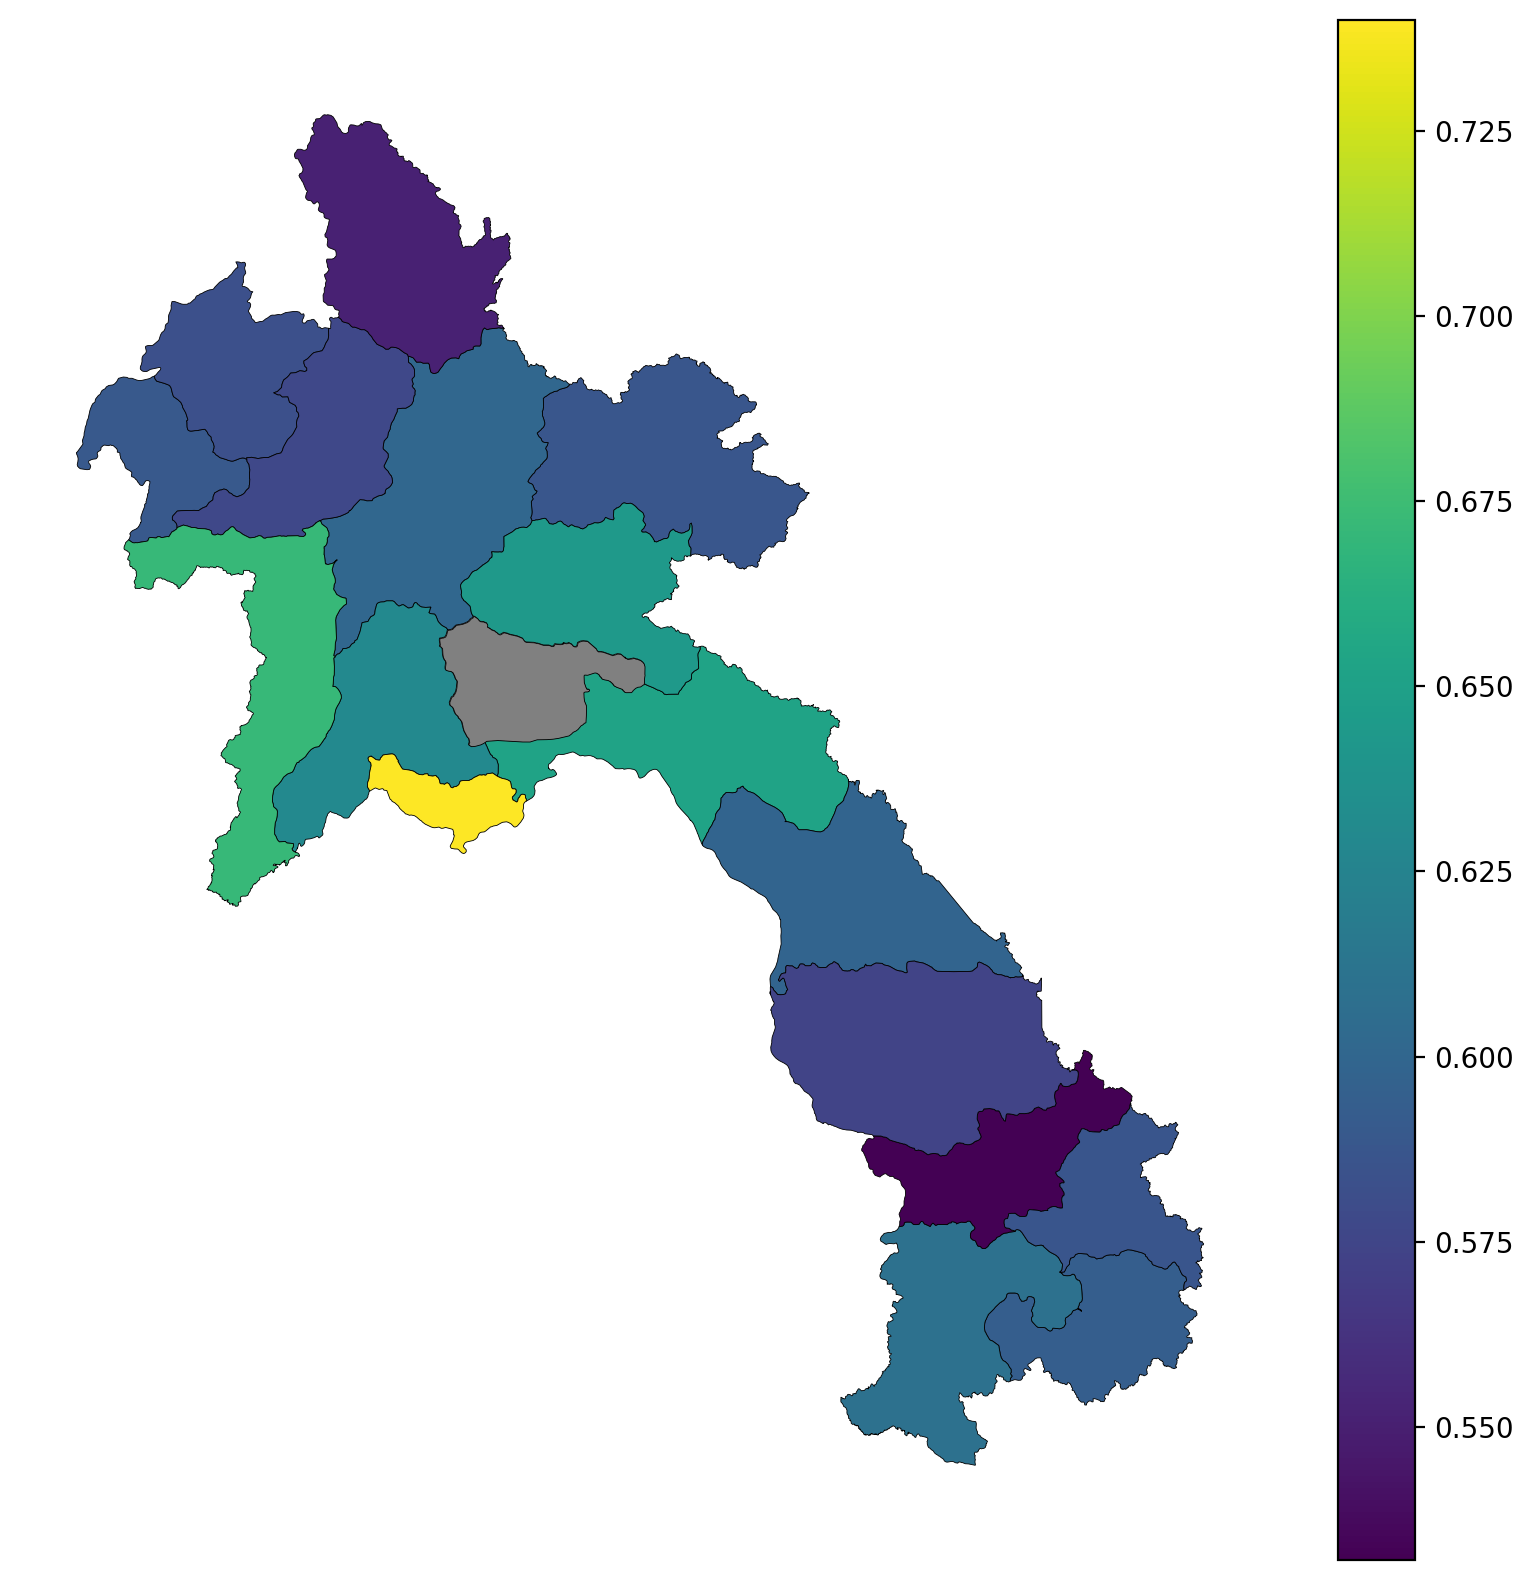

In [26]:
# Mapping a Choropleth Map of HDI by province
HDIMap = SHDI2023.plot(
    column="shdi_value",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={
        "color": "grey",
        "label": "No HDI data", 
    }
)
HDIMap.set_axis_off();
plt.savefig('../figures/HDIChoropleth.png', dpi=300, bbox_inches='tight')

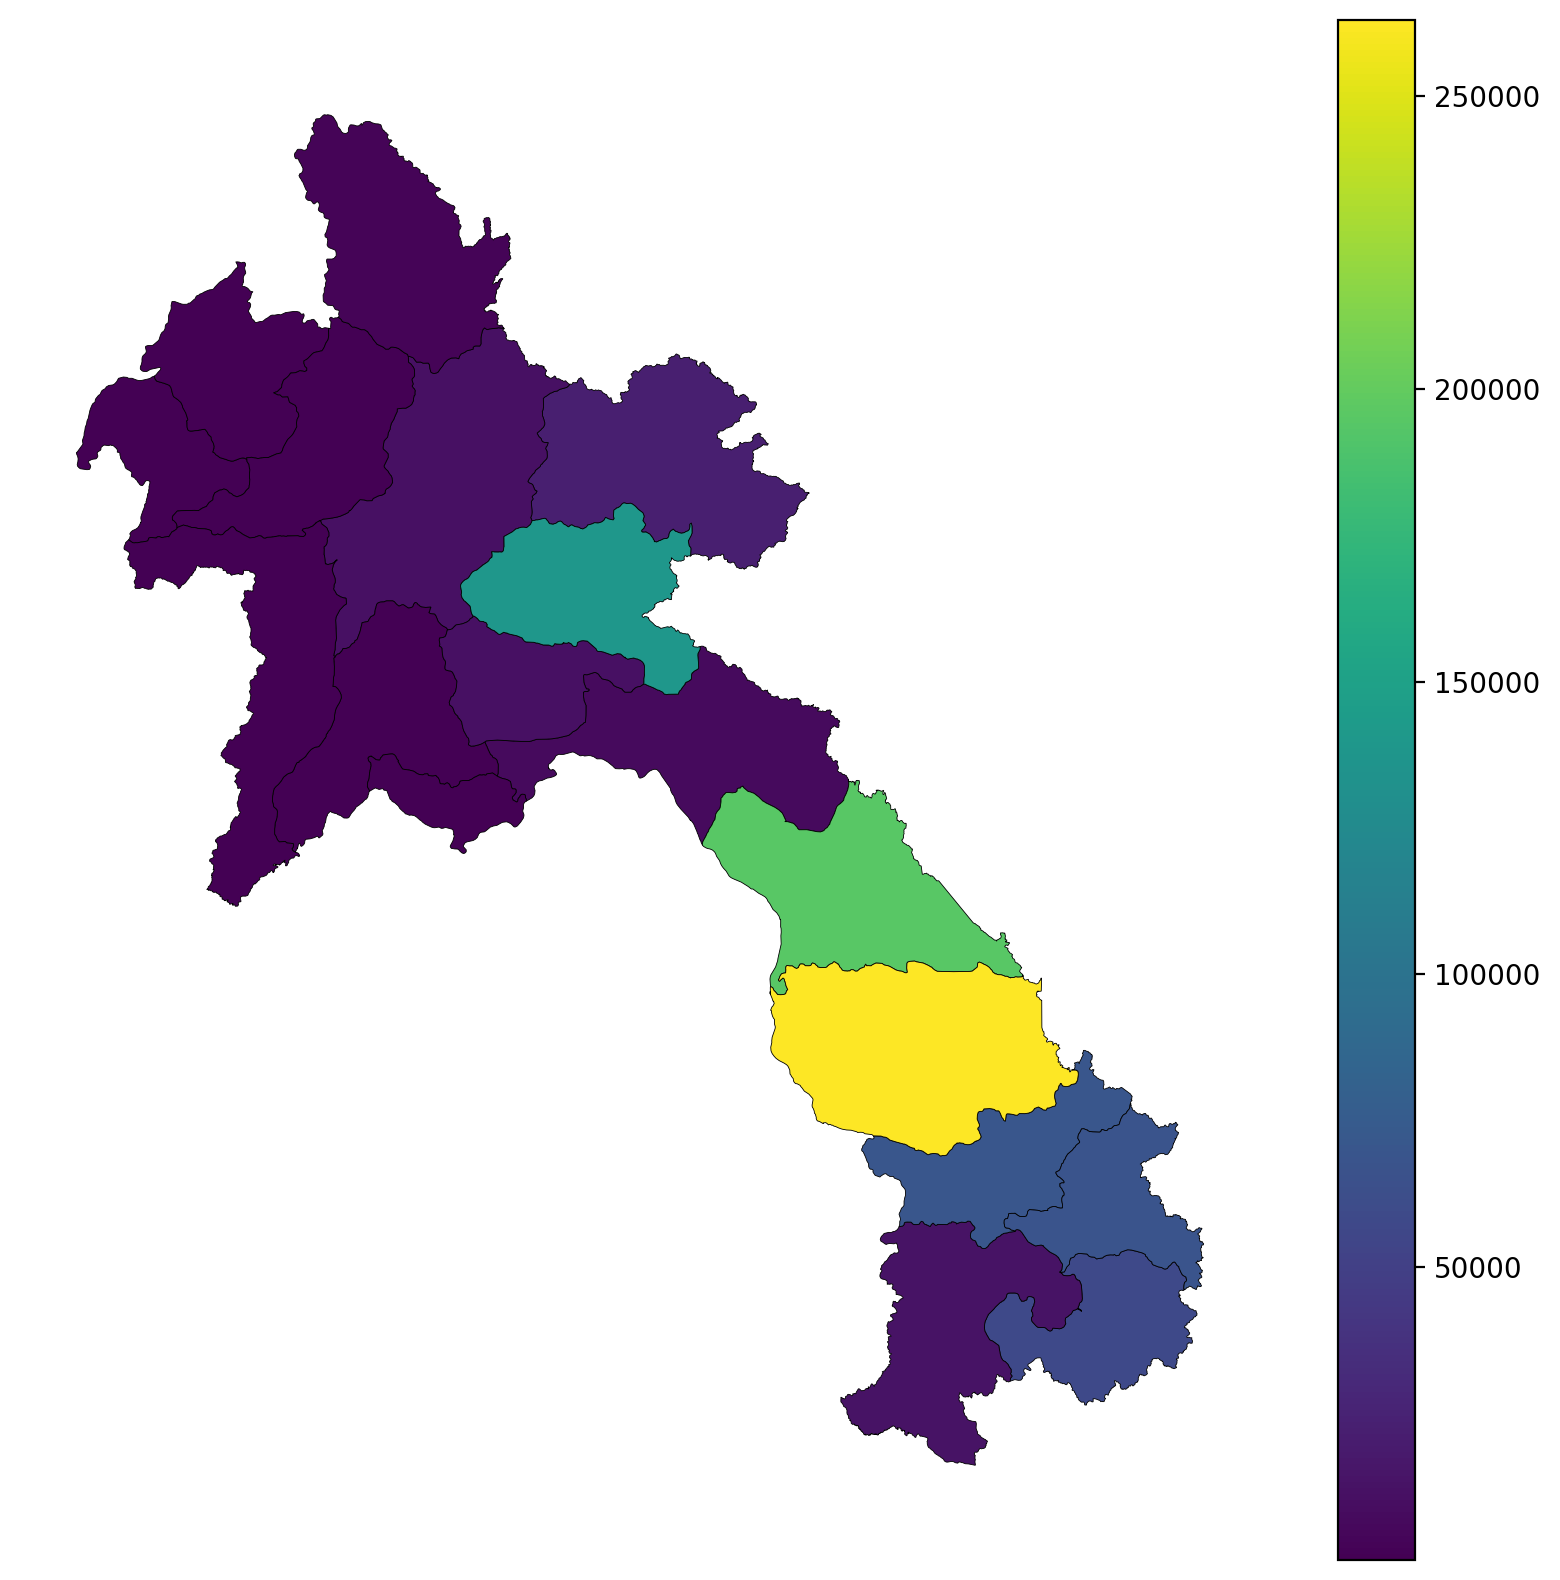

In [39]:
# Chloropleth Map of bombing by province (number of strikes)
BombingMap = ProvincesGDF.plot(
    column="ProvinceBombings",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
)
BombingMap.set_axis_off();
plt.savefig('../figures/BombingChoropleth.png', dpi=300, bbox_inches='tight')

# Leveling Up our Mapping Using Nighttime Lights Data

In [ ]:
# setting file path shortcuts
#raster_path = '../data/VNL_npp_2025_global_vcmslcfg_v2_c202604011200.median_masked.dat.tif'
#src_raster = '../data/laos_nightlights_2025.tif'
#shapefile_path = '../data/LaosBoundaryLvl1.json'

In [ ]:
# dissolving the individual provinces into one single solid outline of the country
laos_boundary = gdf_provinces.dissolve()
shapes = laos_boundary.geometry.values

In [ ]:
# 3. Open the global raster (Lazy load - only reads metadata)
#with rasterio.open(raster_path) as src:
    
    # Check if coordinate systems match before clipping
 #   if src.crs != gdf_provinces.crs:
  #      print(f"Warning: CRS mismatch. Raster is {src.crs}, Shapefile is {gdf_provinces.crs}")
        # If they don't match, you'd convert the shapefile here, but VIIRS and WGS84 usually align.
    
    # 4. Mask/Clip the raster using the Laos geometry
    # crop=True shrinks the bounding box down to just Laos
   # out_image, out_transform = mask(src, shapes, crop=True)
    #out_meta = src.meta

    # 5. Update the metadata to reflect the new, tiny dimensions
    #out_meta.update({
     #   "driver": "GTiff",
      #  "height": out_image.shape[1],
       # "width": out_image.shape[2],
        #"transform": out_transform
    #})

    # 6. Save the new clipped file to your data folder
    #with rasterio.open(src_raster, "w", **out_meta) as dest:
     #   dest.write(out_image)

To make it easier to see the nuances of the night lights data, we apply a lognorm scale. This requires setting the minimum value at a low radiance (0.1) rather than 0. 

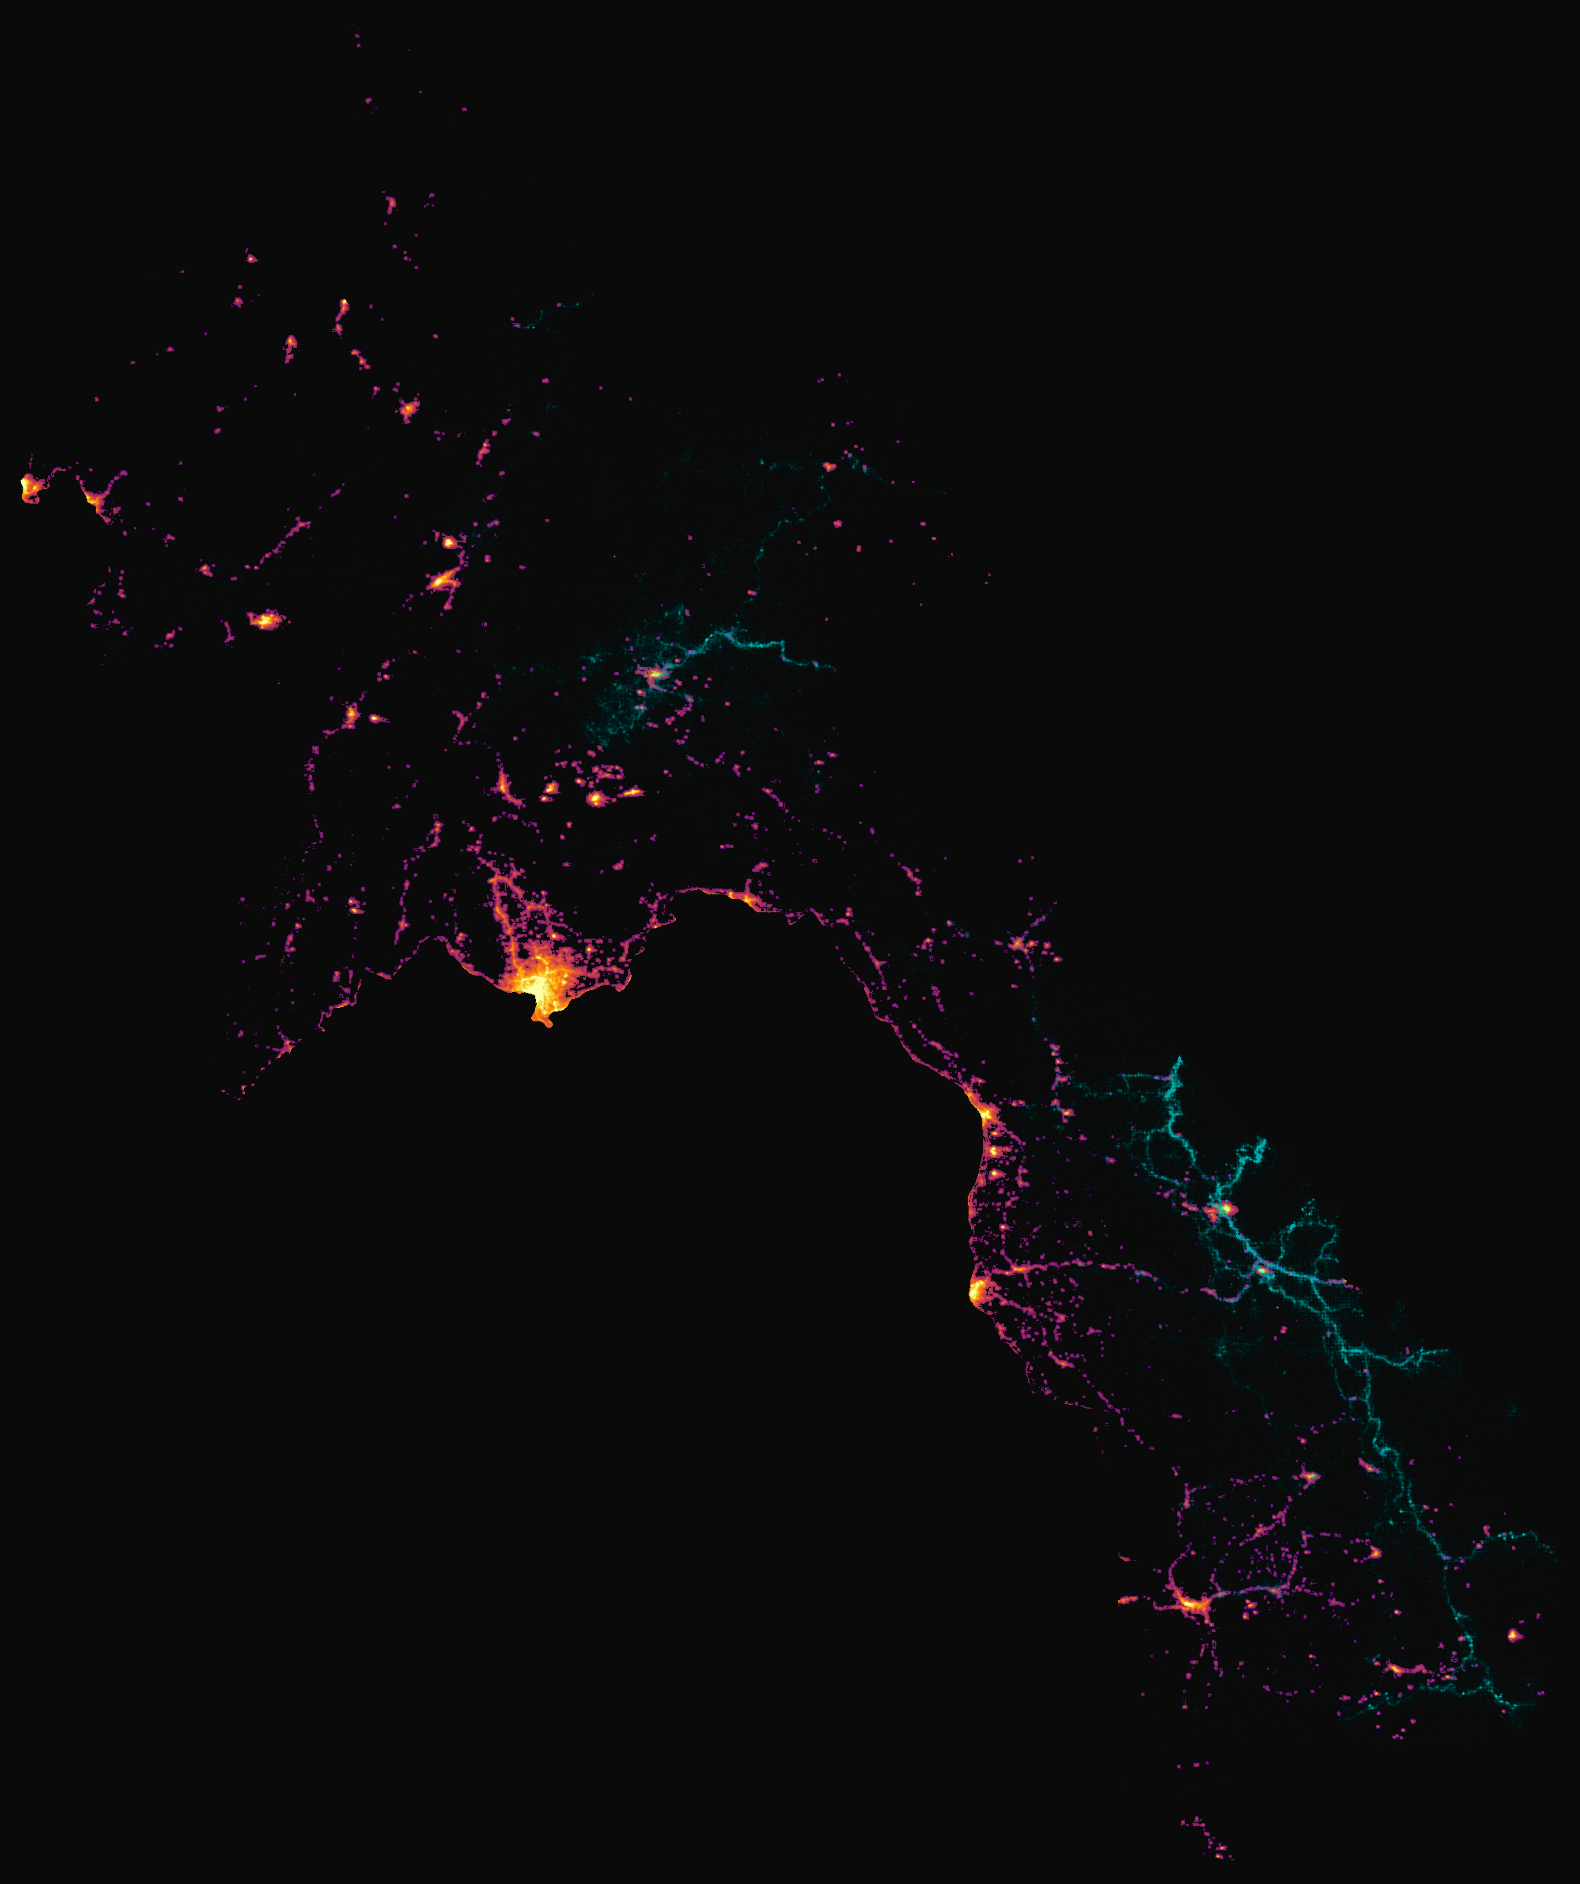

In [10]:
# Opening the night lights file that contains only those in Laos 
src_raster = rasterio.open('../data/LaosNightlights2025.tif')

# Reading the first band (VIIRS data has only 1 band, but plt expects a 2D grid) 
raster_array = src_raster.read(1)

# Setting a low minimum radiance value so we can take lognorm
vmin_val = 0.1

# Setting the maximum of the lognorm to the 99th percentile of brightness, removing outliers to compress the scale 
vmax_stretch = np.percentile(raster_array[raster_array > 0], 99)

# Initializing canvas
fig, ax = plt.subplots(figsize=(8, 16), facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')

# Displaying the night lights data as a raster on the canvas
_ = show(
    src_raster, 
    ax=ax, 
    cmap='inferno', 
    norm=colors.LogNorm(vmin=vmin_val, vmax=vmax_stretch) # from matplotlib .imshow(), which allows logarithmic transformation before assigning colors
)

# Plotting the bombing strikes over the raster data, using random sampling to reduce the saturation and make overlap easier to see 
BombingGDF.sample(frac=0.2, random_state=42).plot(
    ax=ax, color='#00ffff', markersize=1.0, alpha=0.01, linewidth=0
)

ax.axis('off')
plt.tight_layout()
plt.savefig('../figures/LaosLightsPlot.png', dpi=300, bbox_inches='tight')
plt.show()

src_raster.close()

# Integrating District Boundaries

In [ ]:
# Loading district boundaries
gdf_districts = gpd.read_file('../data/LaosBoundaryLvl2.json')
print(gdf_districts.head())

# 3. Set up the plotting canvas
fig, ax = plt.subplots(figsize=(10, 10))

# 4. Plot the GeoDataFrame
# - facecolor: fills the polygons. 'whitesmoke' gives a nice base map feel.
# - edgecolor: color of the province borders.
# - linewidth: thickness of the borders.
gdf_districts.plot(
    ax=ax, 
    facecolor='whitesmoke', 
    edgecolor='black', 
    linewidth=0.8
)

# 5. Formatting the map
plt.title('Laos Administrative Boundaries', fontsize=16, pad=20)

# Turn off the latitude/longitude axis labels for a cleaner, map-like appearance
ax.axis('off')

# 6. Render the plot
plt.tight_layout()
plt.show()